Target part id: 40
Core vertices: 73
Overlap vertices: 1450
Overlap-only vertices: 1377
Overlap parts: [15, 16, 17, 18, 19, 20, 21, 22, 26, 38, 39, 40, 41, 42, 43, 44, 45, 78, 117, 118]
Boundary edge counts by overlap part:
  part 15: 38 edges
  part 16: 34 edges
  part 17: 30 edges
  part 18: 30 edges
  part 19: 30 edges
  part 20: 33 edges
  part 21: 32 edges
  part 22: 32 edges
  part 26: 31 edges
  part 38: 30 edges
  part 39: 32 edges
  part 40: 33 edges
  part 41: 30 edges
  part 42: 32 edges
  part 43: 33 edges
  part 44: 29 edges
  part 45: 30 edges
  part 78: 30 edges
  part 117: 31 edges
  part 118: 31 edges


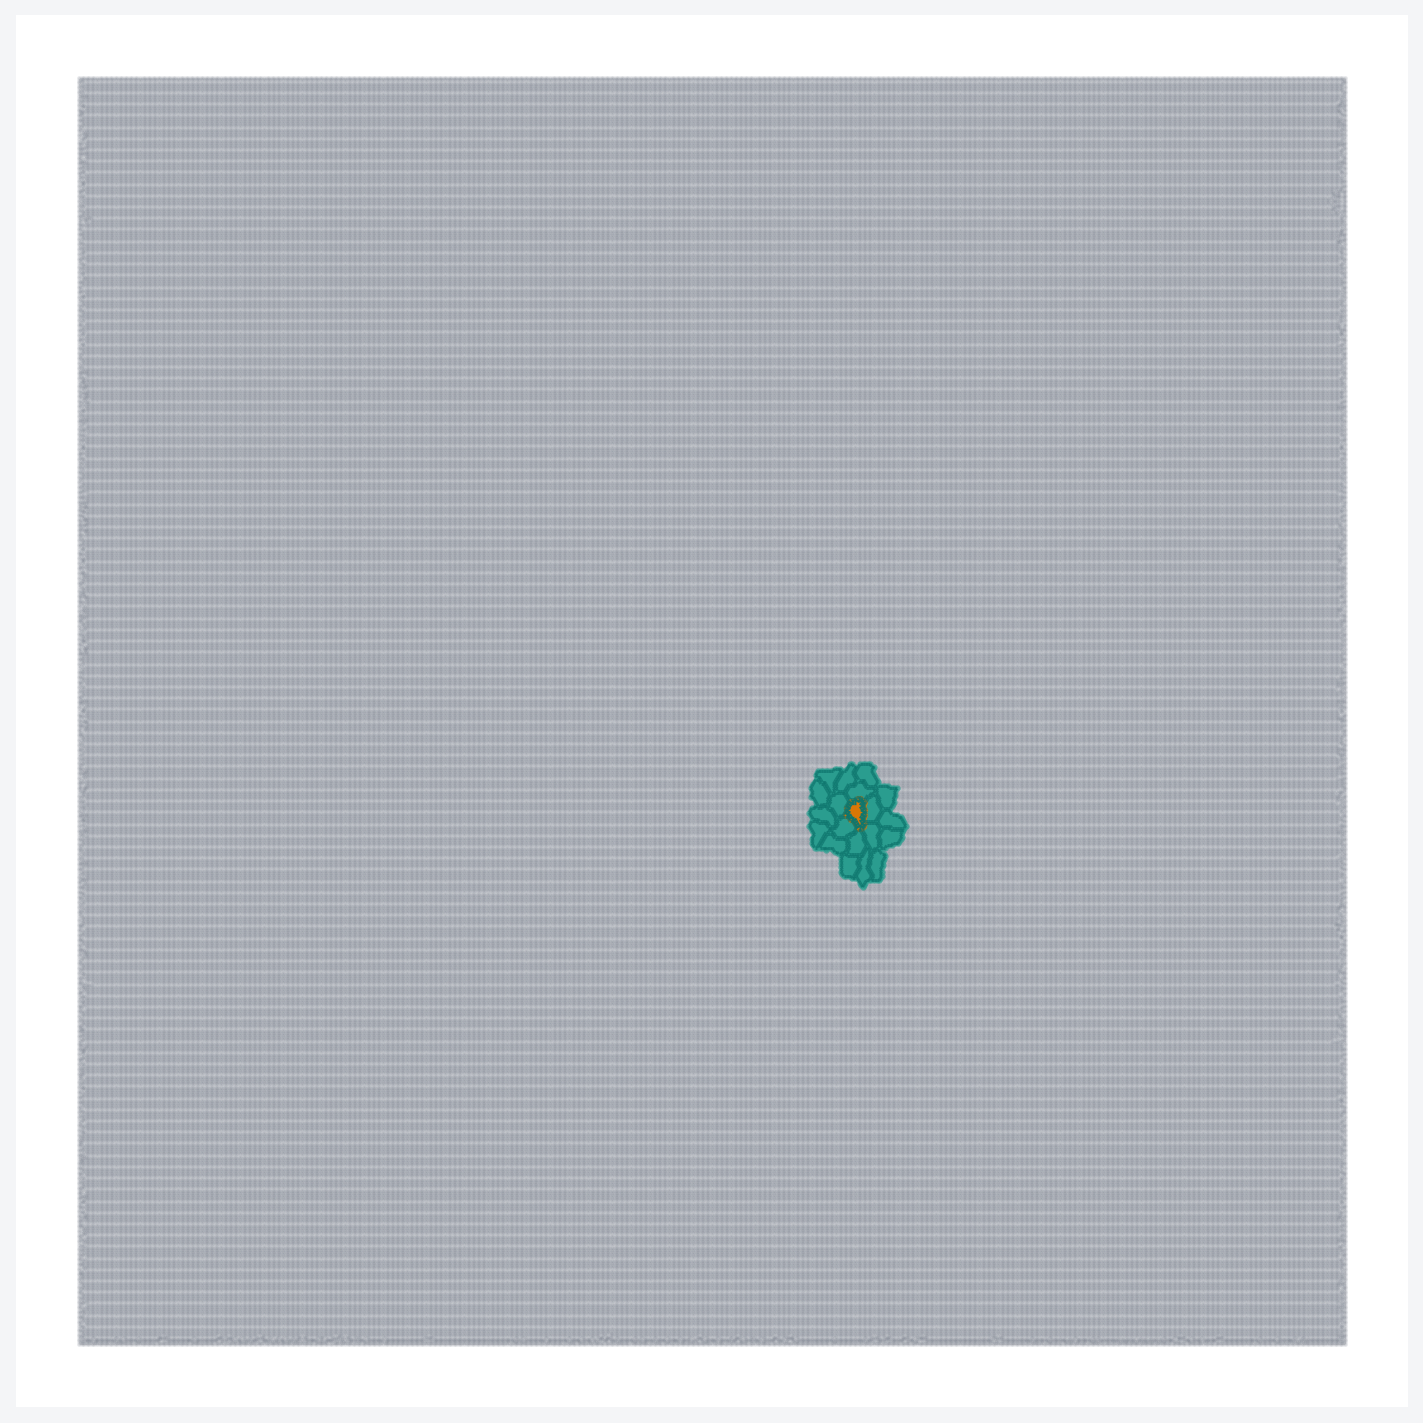

In [1]:
import numpy as np
from collections import defaultdict
from matplotlib.collections import LineCollection, PolyCollection
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-white')


def read_msh_file(filename):
    """Read a .msh file and extract nodes and elements."""
    nodes = {}
    elements = []

    with open(filename, 'r') as f:
        lines = f.readlines()

    node_start = None
    node_end = None
    for i, line in enumerate(lines):
        if '$Nodes' in line:
            node_start = i + 1
        elif '$EndNodes' in line:
            node_end = i
            break

    if node_start is not None and node_end is not None:
        for i in range(node_start + 1, node_end):
            parts = lines[i].strip().split()
            node_id = int(parts[0])
            x, y = float(parts[1]), float(parts[2])
            nodes[node_id] = (x, y)

    elem_start = None
    elem_end = None
    for i, line in enumerate(lines):
        if '$Elements' in line:
            elem_start = i + 1
        elif '$EndElements' in line:
            elem_end = i
            break

    if elem_start is not None and elem_end is not None:
        for i in range(elem_start + 1, elem_end):
            parts = lines[i].strip().split()
            elem_type = int(parts[1])
            num_tags = int(parts[2])
            node_list = [
                int(parts[3 + num_tags + j])
                for j in range(len(parts) - 3 - num_tags)
            ]
            elements.append((elem_type, node_list))

    return nodes, elements


def read_int_list(path):
    with open(path, 'r') as f:
        txt = f.read().strip()
    if not txt:
        return []
    return [int(x) for x in txt.split()]


# -----------------------------
# Config (edit target_part_id)
# -----------------------------
mesh_path = '../mesh/rect02.msh'
data_dir = '../data'
target_part_id = 40

nodes, elements = read_msh_file(mesh_path)
node_ids = sorted(nodes.keys())
node_coords = np.array([nodes[nid] for nid in node_ids])

parts = read_int_list(f'{data_dir}/neighbours_part.txt')
core_vertices = set(read_int_list(f'{data_dir}/neighbours_vertices_{target_part_id}.txt'))
overlap_vertices = set(read_int_list(f'{data_dir}/neighbours_verticesCEM_{target_part_id}.txt'))
overlap_parts = read_int_list(f'{data_dir}/neighbours_overlapping_parts_{target_part_id}.txt')
overlap_only = overlap_vertices - core_vertices

if len(parts) < len(node_ids):
    print('Warning: neighbours_part.txt has fewer entries than mesh nodes; unmatched nodes will be treated as outside.')

if target_part_id not in overlap_parts:
    overlap_parts = sorted(set(overlap_parts + [target_part_id]))

# Load core-vertex sets for all overlap subdomains.
overlap_part_core = {}
for p in overlap_parts:
    overlap_part_core[p] = set(read_int_list(f'{data_dir}/neighbours_vertices_{p}.txt'))

# Map mesh node id -> global index used by exported files (assumed node_id-1)
node_index = {nid: nid - 1 for nid in node_ids}

# Build category masks: 0 outside, 1 overlap-only, 2 core
category = np.zeros(len(node_ids), dtype=int)
for i, nid in enumerate(node_ids):
    gid = node_index[nid]
    if gid in core_vertices:
        category[i] = 2
    elif gid in overlap_only:
        category[i] = 1

# Plot
fig, ax = plt.subplots(figsize=(11, 9), dpi=160)
fig.patch.set_facecolor('#f4f5f7')
ax.set_facecolor('#ffffff')

faces_outside, faces_overlap, faces_core = [], [], []
edge_segs = []

# Boundary edges for each overlap subdomain.
# We classify a triangle as belonging to subdomain p when all 3 vertices
# are in that subdomain's core-vertex set. Boundary edges are edges that
# appear only once in that subdomain's triangle set.
boundary_edge_counts = {p: defaultdict(int) for p in overlap_parts}

for elem_type, node_list in elements:
    if elem_type != 2 or len(node_list) != 3:
        continue

    pts = [nodes[node_list[0]], nodes[node_list[1]], nodes[node_list[2]]]
    edge_segs.extend([[pts[0], pts[1]], [pts[1], pts[2]], [pts[2], pts[0]]])

    gids = [node_index.get(node_list[k], -1) for k in range(3)]
    in_core = all(g in core_vertices for g in gids)
    in_overlap = all(g in overlap_vertices for g in gids)

    if in_core:
        faces_core.append(pts)
    elif in_overlap:
        faces_overlap.append(pts)
    else:
        faces_outside.append(pts)

    # Accumulate edge multiplicity for each overlap subdomain.
    for p in overlap_parts:
        p_core = overlap_part_core[p]
        if all(g in p_core for g in gids):
            tri_edges = [
                tuple(sorted((gids[0], gids[1]))),
                tuple(sorted((gids[1], gids[2]))),
                tuple(sorted((gids[2], gids[0]))),
            ]
            for e in tri_edges:
                boundary_edge_counts[p][e] += 1

if faces_outside:
    poly_out = PolyCollection(
        faces_outside,
        facecolors='#eef1f4',
        edgecolors='white',
        linewidths=0.2,
        alpha=0.95,
        zorder=1,
    )
    ax.add_collection(poly_out)

if faces_overlap:
    poly_overlap = PolyCollection(
        faces_overlap,
        facecolors='#7fc8a9',
        edgecolors='white',
        linewidths=0.25,
        alpha=0.78,
        zorder=2,
    )
    ax.add_collection(poly_overlap)

if faces_core:
    poly_core = PolyCollection(
        faces_core,
        facecolors='#f18f01',
        edgecolors='white',
        linewidths=0.28,
        alpha=0.92,
        zorder=3,
    )
    ax.add_collection(poly_core)

if edge_segs:
    lc = LineCollection(
        edge_segs,
        colors='#d9d9d9',
        linewidths=0.35,
        alpha=0.55,
        zorder=0,
    )
    ax.add_collection(lc)

outside_mask = category == 0
overlap_mask = category == 1
core_mask = category == 2

if np.any(outside_mask):
    ax.scatter(
        node_coords[outside_mask, 0],
        node_coords[outside_mask, 1],
        c='#6b7280',
        s=1.4,
        alpha=0.16,
        zorder=4,
        rasterized=True,
        label='Outside',
    )
if np.any(overlap_mask):
    ax.scatter(
        node_coords[overlap_mask, 0],
        node_coords[overlap_mask, 1],
        c='#2a9d8f',
        s=3.5,
        alpha=0.65,
        zorder=5,
        rasterized=True,
        label='Overlap only',
    )
if np.any(core_mask):
    ax.scatter(
        node_coords[core_mask, 0],
        node_coords[core_mask, 1],
        c='#d97706',
        s=5.0,
        alpha=0.82,
        zorder=6,
        rasterized=True,
        label='Core',
    )

# Draw one boundary layer per overlap subdomain with a unified color.
boundary_color = '#0f766e'
boundary_counts = {}
for p in sorted(overlap_parts):
    boundary_edges = [e for e, c in boundary_edge_counts[p].items() if c == 1]
    boundary_counts[p] = len(boundary_edges)
    if not boundary_edges:
        continue

    segs = [
        [nodes[e[0] + 1], nodes[e[1] + 1]]
        for e in boundary_edges
        if (e[0] + 1) in nodes and (e[1] + 1) in nodes
    ]
    if not segs:
        continue

    lw = 2.4 if p == target_part_id else 1.35
    alpha = 0.98 if p == target_part_id else 0.75
    label = f'Boundary part {p}'

    boundary_lc = LineCollection(
        segs,
        colors=[boundary_color],
        linewidths=lw,
        alpha=alpha,
        zorder=8,
        label=label,
    )
    ax.add_collection(boundary_lc)

ax.set_aspect('equal')
# ax.set_title(
#     f'Subdomain {target_part_id}: core + overlap neighborhood ({len(overlap_parts)} overlap parts)',
#     pad=10,
#     fontweight='semibold',
# )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

# handles, labels = ax.get_legend_handles_labels()
# if len(labels) > 16:
#     # Keep the main semantic labels and compress boundary labels when many.
#     keep = []
#     for h, l in zip(handles, labels):
#         if l in {'Outside', 'Overlap only', 'Core', f'Boundary part {target_part_id}'}:
#             keep.append((h, l))
#     handles = [x[0] for x in keep]
#     labels = [x[1] for x in keep]

# leg = ax.legend(handles, labels, loc='upper right', frameon=True, framealpha=0.95)
# leg.get_frame().set_edgecolor('#b5b5b5')
# leg.get_frame().set_linewidth(0.6)

plt.tight_layout()
plt.savefig('overlap4.png', dpi=150, bbox_inches='tight', pad_inches=0.1)

print(f'Target part id: {target_part_id}')
print(f'Core vertices: {len(core_vertices)}')
print(f'Overlap vertices: {len(overlap_vertices)}')
print(f'Overlap-only vertices: {len(overlap_only)}')
print(f'Overlap parts: {sorted(overlap_parts)}')
print('Boundary edge counts by overlap part:')
for p in sorted(boundary_counts):
    print(f'  part {p}: {boundary_counts[p]} edges')